In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("brijbhushannanda1979/bigmart-sales-data")

print("Path to dataset files:", path)

100%|██████████| 307k/307k [00:00<00:00, 887kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/brijbhushannanda1979/bigmart-sales-data/versions/1


In [4]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/root/.cache/kagglehub/datasets/brijbhushannanda1979/bigmart-sales-data/versions/1/Test.csv
/root/.cache/kagglehub/datasets/brijbhushannanda1979/bigmart-sales-data/versions/1/Train.csv


In [6]:
df = pd.read_csv(os.path.join(path, 'Train.csv'))
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [7]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(8523, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB
None
       Item_Weight  Item_Visi

In [8]:
df = df.dropna()

In [10]:
df['Item_Weight'] = df['Item_Weight'].fillna(
    df['Item_Weight'].mean()
)

df['Outlet_Size'] = df['Outlet_Size'].fillna(
    df['Outlet_Size'].mode()[0]
)

In [11]:
df[['Item_Weight','Outlet_Size']].isnull().sum()

,0
Item_Weight,0
Outlet_Size,0


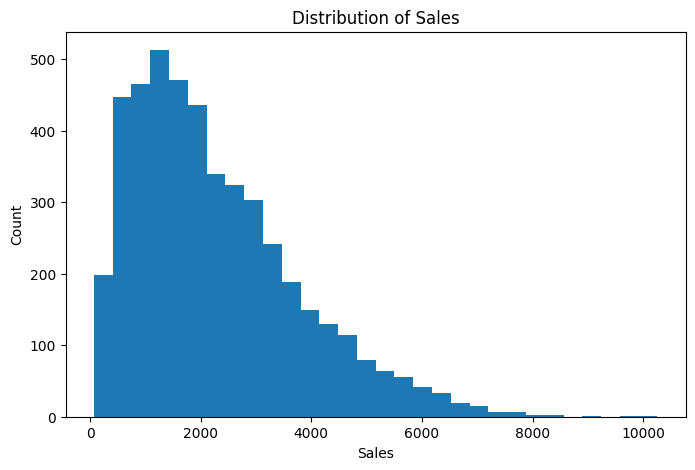

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df['Item_Outlet_Sales'], bins=30)

plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Count')

plt.show()

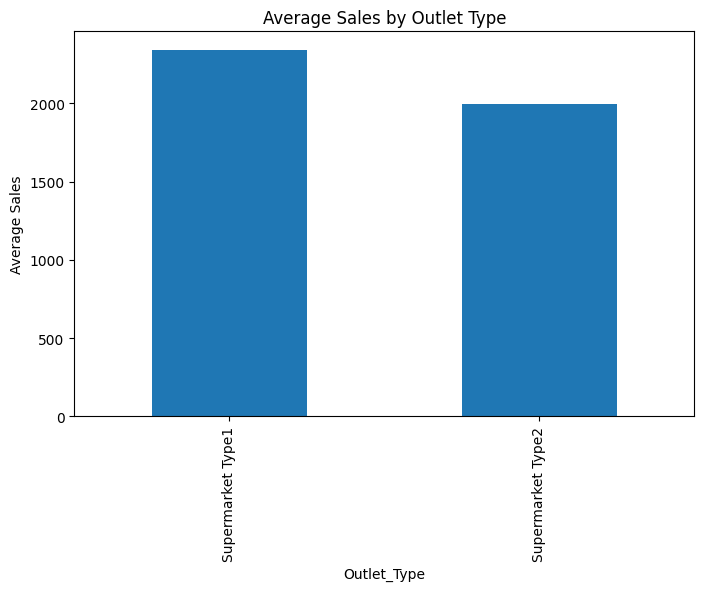

In [13]:
sales_by_outlet = df.groupby(
    'Outlet_Type'
)['Item_Outlet_Sales'].mean()

sales_by_outlet.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Sales by Outlet Type')
plt.ylabel('Average Sales')

plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [15]:
X = df.drop(['Item_Outlet_Sales'],axis=1)
y = df['Item_Outlet_Sales']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [18]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
import numpy as np

mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 820.340563352688
RMSE : 1105.1970073264083
R2 Score : 0.43475940076219644


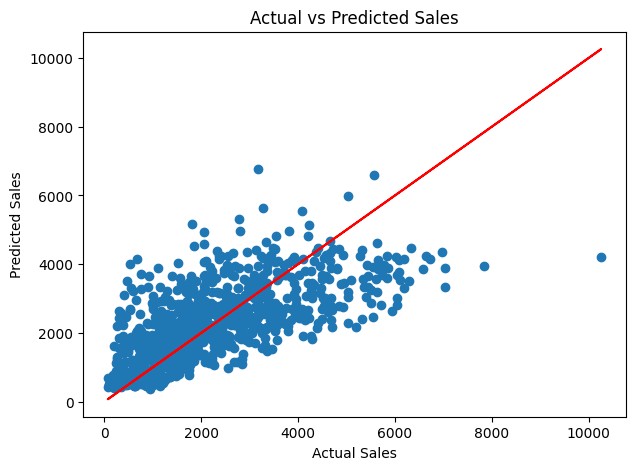

In [21]:
plt.figure(figsize=(7,5))

plt.scatter(y_test,y_pred)
plt.plot(y_test,y_test,color='red')

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

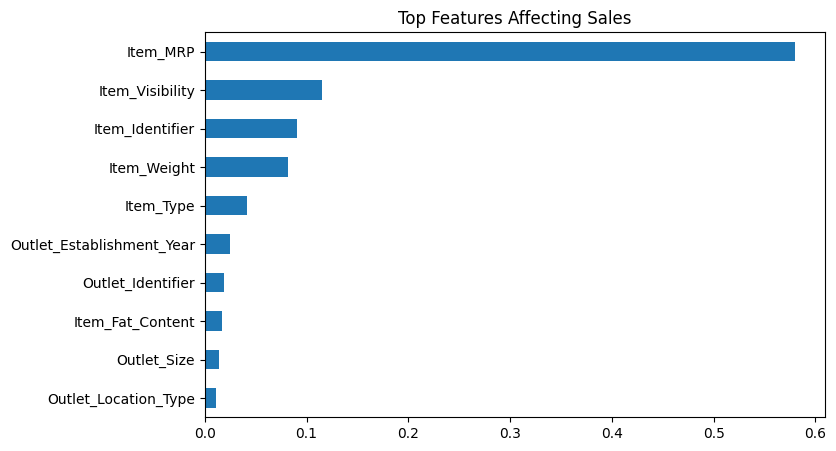

In [22]:
importance = pd.Series(model.feature_importances_,index=X.columns)
importance.sort_values().tail(10).plot(kind='barh',figsize=(8,5))
plt.title("Top Features Affecting Sales")
plt.show()